In [4]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import joblib

print("All required libraries are available.")

All required libraries are available.


In [5]:
import seaborn as sns
import pandas as pd

# Load Titanic dataset from Seaborn
df = sns.load_dataset("titanic")

# Save the raw dataset as the offline fallback
df.to_csv("titanic.csv", index=False)

print("Titanic dataset loaded successfully.")
print("Shape:", df.shape)
print("Saved as titanic.csv")

Titanic dataset loaded successfully.
Shape: (891, 15)
Saved as titanic.csv


In [6]:
# Dataset information
print("=== DATASET INFO ===")
df.info()

# Statistical summary
print("\n=== DESCRIPTIVE STATISTICS ===")
print(df.describe())

# Dataset shape
print("\n=== DATASET SHAPE ===")
print(df.shape)

# Missing-value percentages
print("\n=== MISSING VALUE PERCENTAGES ===")

missing_percent = (
    df.isnull()
      .mean()
      .mul(100)
)

missing_percent = missing_percent[missing_percent > 0]

print(missing_percent)

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

=== DESCRIPTIVE STATISTICS ===
         survived      pcl

In [7]:
# Make a copy so the original loaded data remains available
clean_df = df.copy()

# 1. Drop rows where embarked or embark_town are missing
# Missing rate for each is only 0.22%, which is under 5%.
clean_df = clean_df.dropna(
    subset=["embarked", "embark_town"]
)

# 2. Impute age because 19.87% is between 5% and 30%.
# Use the median because age can contain outliers.
clean_df["age"] = clean_df["age"].fillna(
    clean_df["age"].median()
)

# 3. Drop deck because 77.22% is missing.
# Imputing such a large proportion would be unreliable.
clean_df = clean_df.drop(
    columns=["deck"]
)

print("Original shape:", df.shape)
print("Cleaned shape:", clean_df.shape)

print("\nRemaining missing values:")
print(clean_df.isnull().sum())

Original shape: (891, 15)
Cleaned shape: (889, 14)

Remaining missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [8]:
print("=== CLEANED DATASET ===")
print("Shape:", clean_df.shape)

print("\nMissing values:")
print(clean_df.isnull().sum())

print("\nData types:")
print(clean_df.dtypes)

=== CLEANED DATASET ===
Shape: (889, 14)

Missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

Data types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
embark_town      object
alive            object
alone              bool
dtype: object


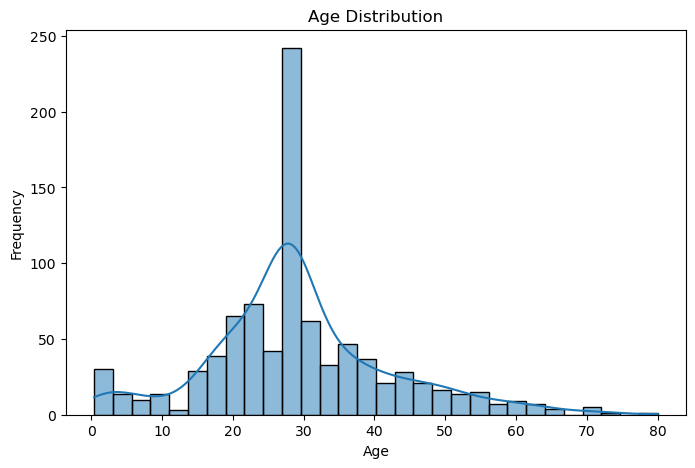

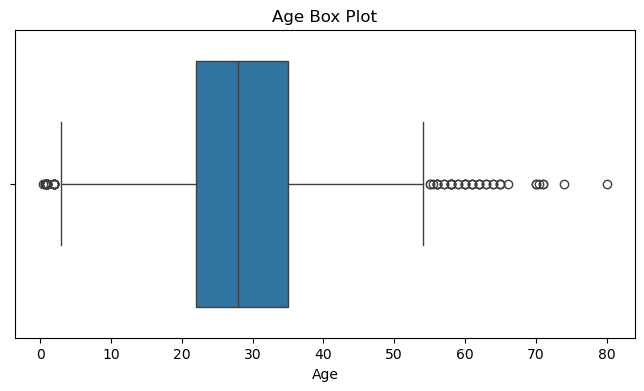

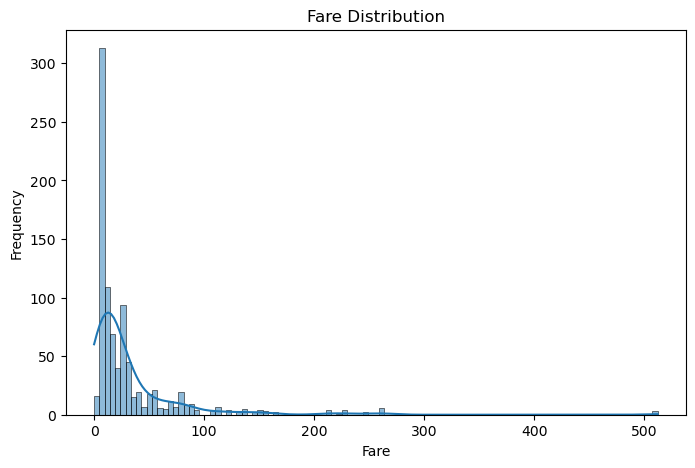

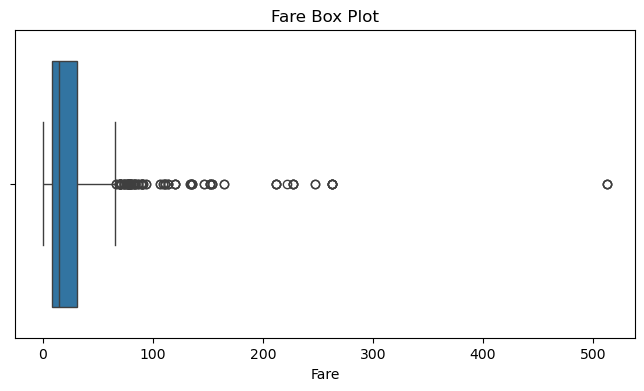

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram and box plot for Age
plt.figure(figsize=(8, 5))
sns.histplot(clean_df["age"], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=clean_df["age"])
plt.title("Age Box Plot")
plt.xlabel("Age")
plt.show()


# Histogram and box plot for Fare
plt.figure(figsize=(8, 5))
sns.histplot(clean_df["fare"], kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=clean_df["fare"])
plt.title("Fare Box Plot")
plt.xlabel("Fare")
plt.show()

In [11]:
def iqr_outlier_count(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]

    return Q1, Q3, IQR, lower_bound, upper_bound, len(outliers)


# Age outliers
age_Q1, age_Q3, age_IQR, age_lower, age_upper, age_outliers = (
    iqr_outlier_count(clean_df["age"])
)

# Fare outliers
fare_Q1, fare_Q3, fare_IQR, fare_lower, fare_upper, fare_outliers = (
    iqr_outlier_count(clean_df["fare"])
)

print("=== AGE IQR ANALYSIS ===")
print("Q1:", age_Q1)
print("Q3:", age_Q3)
print("IQR:", age_IQR)
print("Lower bound:", age_lower)
print("Upper bound:", age_upper)
print("Number of outliers:", age_outliers)

print("\n=== FARE IQR ANALYSIS ===")
print("Q1:", fare_Q1)
print("Q3:", fare_Q3)
print("IQR:", fare_IQR)
print("Lower bound:", fare_lower)
print("Upper bound:", fare_upper)
print("Number of outliers:", fare_outliers)

=== AGE IQR ANALYSIS ===
Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower bound: 2.5
Upper bound: 54.5
Number of outliers: 65

=== FARE IQR ANALYSIS ===
Q1: 7.8958
Q3: 31.0
IQR: 23.1042
Lower bound: -26.7605
Upper bound: 65.6563
Number of outliers: 114


In [12]:
fare_mean = clean_df["fare"].mean()
fare_median = clean_df["fare"].median()
fare_mode = clean_df["fare"].mode()[0]

print("=== FARE SUMMARY ===")
print("Mean:", fare_mean)
print("Median:", fare_median)
print("Mode:", fare_mode)

if fare_mean > fare_median > fare_mode:
    print("\nFare distribution is right-skewed.")
elif fare_mean < fare_median < fare_mode:
    print("\nFare distribution is left-skewed.")
else:
    print("\nFare distribution is not clearly classified by mean/median/mode ordering.")

=== FARE SUMMARY ===
Mean: 32.09668087739032
Median: 14.4542
Mode: 8.05

Fare distribution is right-skewed.


In [13]:
print("=== SURVIVAL RATE BY SEX ===")

for sex in clean_df["sex"].unique():
    group = clean_df[clean_df["sex"] == sex]
    survival_rate = group["survived"].mean() * 100
    print(f"{sex}: {survival_rate:.2f}%")


print("\n=== SURVIVAL RATE BY PCLASS ===")

for pclass in sorted(clean_df["pclass"].unique()):
    group = clean_df[clean_df["pclass"] == pclass]
    survival_rate = group["survived"].mean() * 100
    print(f"Class {pclass}: {survival_rate:.2f}%")


print("\n=== SURVIVAL RATE BY SEX AND PCLASS ===")

for sex in clean_df["sex"].unique():
    for pclass in sorted(clean_df["pclass"].unique()):
        group = clean_df[
            (clean_df["sex"] == sex) &
            (clean_df["pclass"] == pclass)
        ]

        if len(group) > 0:
            survival_rate = group["survived"].mean() * 100
            print(
                f"{sex}, Class {pclass}: "
                f"{survival_rate:.2f}%"
            )

=== SURVIVAL RATE BY SEX ===
male: 18.89%
female: 74.04%

=== SURVIVAL RATE BY PCLASS ===
Class 1: 62.62%
Class 2: 47.28%
Class 3: 24.24%

=== SURVIVAL RATE BY SEX AND PCLASS ===
male, Class 1: 36.89%
male, Class 2: 15.74%
male, Class 3: 13.54%
female, Class 1: 96.74%
female, Class 2: 92.11%
female, Class 3: 50.00%


=== CORRELATION MATRIX ===
          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


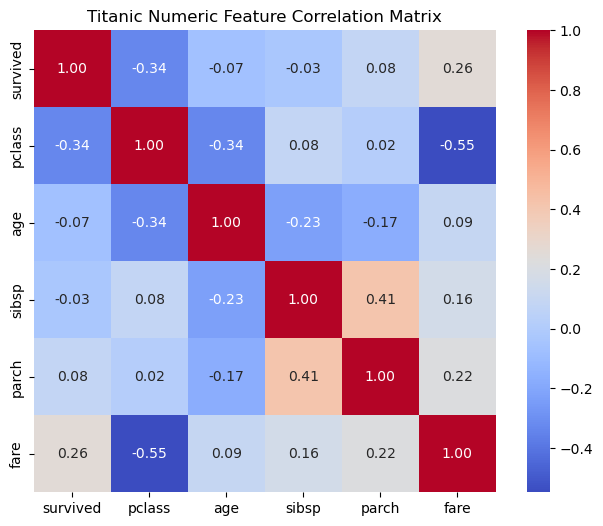


=== TWO STRONGEST CORRELATIONS ===
pclass  fare    -0.548193
sibsp   parch    0.414542
dtype: float64


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Exactly the six required columns
corr_cols = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = clean_df[corr_cols].corr()

print("=== CORRELATION MATRIX ===")
print(corr_matrix)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Titanic Numeric Feature Correlation Matrix")
plt.show()


# Find the two strongest absolute off-diagonal correlations
corr_pairs = (
    corr_matrix
    .where(
        np.triu(
            np.ones(corr_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
)

print("\n=== TWO STRONGEST CORRELATIONS ===")
print(corr_pairs.head(2))

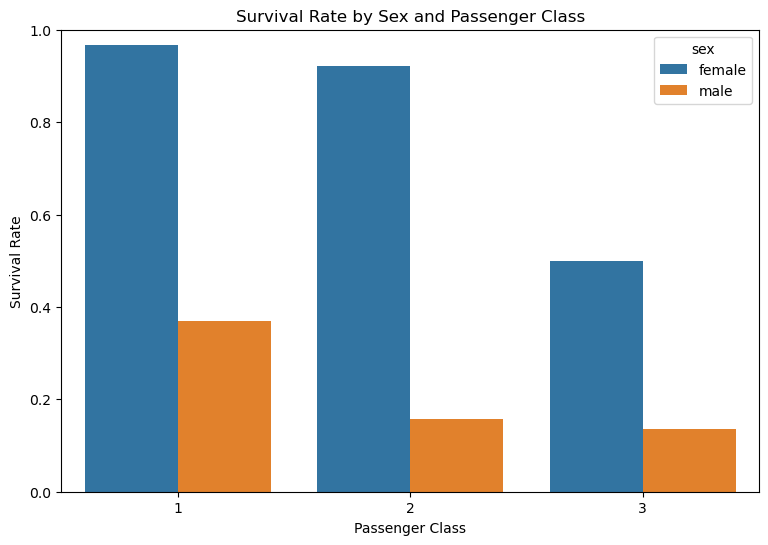

In [15]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=clean_df,
    x="pclass",
    y="survived",
    hue="sex",
    errorbar=None
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

plt.show()

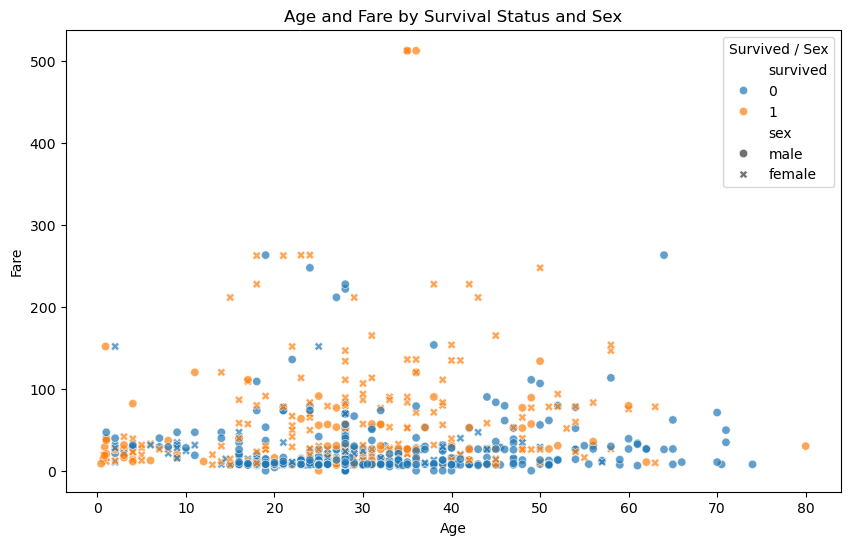

In [16]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clean_df,
    x="age",
    y="fare",
    hue="survived",
    style="sex",
    alpha=0.7
)

plt.title("Age and Fare by Survival Status and Sex")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend(title="Survived / Sex")

plt.show()

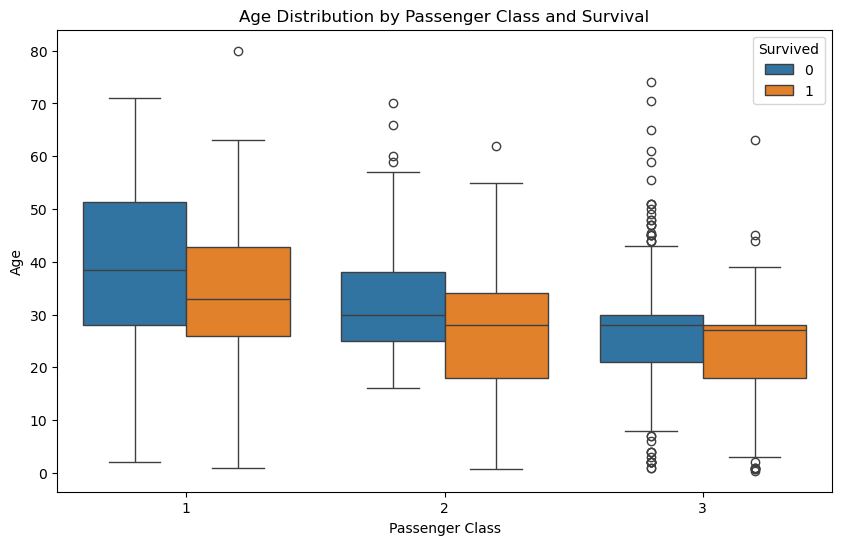

In [17]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=clean_df,
    x="pclass",
    y="age",
    hue="survived"
)

plt.title("Age Distribution by Passenger Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.legend(title="Survived")

plt.show()

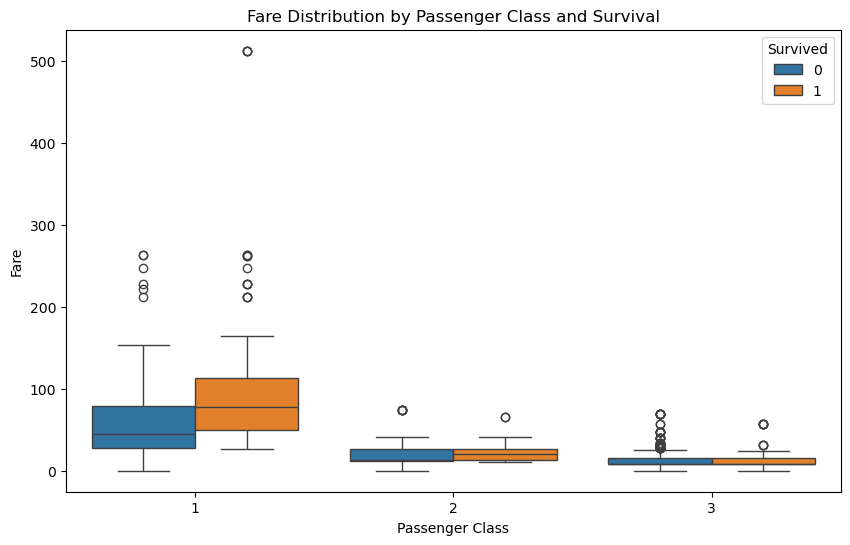

In [18]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=clean_df,
    x="pclass",
    y="fare",
    hue="survived"
)

plt.title("Fare Distribution by Passenger Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.legend(title="Survived")

plt.show()

### Multivariate Chart Interpretations

**1. Survival Rate by Sex and Passenger Class**  
Survival rates vary substantially by both sex and passenger class. Female passengers had higher survival rates than male passengers across all three classes, while survival generally decreased from first class to third class.

**2. Age and Fare by Survival Status and Sex**  
The scatter plot shows how age and fare vary across survival status and sex. Higher fares are concentrated more strongly among first-class passengers, while the survival groups show considerable overlap across ages and fares.

**3. Age Distribution by Passenger Class and Survival**  
Age distributions differ across passenger classes, with the box plots showing variation in median age and spread. Within each class, the age distributions of survivors and non-survivors overlap, indicating that age alone does not completely separate the two survival groups.

**4. Fare Distribution by Passenger Class and Survival**  
Fare varies strongly across passenger classes, with first-class passengers generally paying higher fares than passengers in lower classes. Within each class, survivors and non-survivors show overlapping fare distributions, although differences in fare levels are visible between the survival groups.

In [19]:
from sklearn.preprocessing import StandardScaler

# Select only age and fare for EDA standardization
eda_standardized = clean_df[["age", "fare"]].copy()

# Check values before standardization
print("=== BEFORE STANDARDIZATION ===")
print("Mean:")
print(eda_standardized.mean())

print("\nStandard deviation:")
print(eda_standardized.std(ddof=0))


# Apply z-score standardization
scaler = StandardScaler()

eda_standardized[["age", "fare"]] = scaler.fit_transform(
    eda_standardized[["age", "fare"]]
)


# Check values after standardization
print("\n=== AFTER STANDARDIZATION ===")
print("Mean:")
print(eda_standardized.mean())

print("\nStandard deviation:")
print(eda_standardized.std(ddof=0))

=== BEFORE STANDARDIZATION ===
Mean:
age     29.315152
fare    32.096681
dtype: float64

Standard deviation:
age     12.977627
fare    49.669545
dtype: float64

=== AFTER STANDARDIZATION ===
Mean:
age     2.717486e-16
fare    1.398706e-16
dtype: float64

Standard deviation:
age     1.0
fare    1.0
dtype: float64


In [20]:
from sklearn.model_selection import train_test_split

# Features and target
X = clean_df.drop(columns=["survived"])
y = clean_df["survived"]

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=== DATA SPLIT ===")
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\n=== OVERALL CLASS BALANCE ===")
print(y.value_counts(normalize=True))

print("\n=== TRAINING CLASS BALANCE ===")
print(y_train.value_counts(normalize=True))

print("\n=== TESTING CLASS BALANCE ===")
print(y_test.value_counts(normalize=True))

=== DATA SPLIT ===
Training shape: (711, 13)
Testing shape: (178, 13)

=== OVERALL CLASS BALANCE ===
survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64

=== TRAINING CLASS BALANCE ===
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

=== TESTING CLASS BALANCE ===
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Modeling features
model_features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = clean_df[model_features]
y = clean_df["survived"]

# Separate feature types
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

# Numeric preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combined preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Modeling features:")
print(model_features)

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nPreprocessing pipeline created successfully.")

Modeling features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

Numeric features:
['pclass', 'age', 'sibsp', 'parch', 'fare']

Categorical features:
['sex', 'embarked']

Preprocessing pipeline created successfully.


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Define the three classifiers
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        oob_score=True
    )
}

# Create a complete pipeline for each model
model_pipelines = {}

for name, model in models.items():
    model_pipelines[name] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

# Train all models on the training data only
for name, pipeline in model_pipelines.items():
    pipeline.fit(X_train, y_train)
    print(f"{name} trained successfully.")

print("\nAll three models trained.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.

All three models trained.


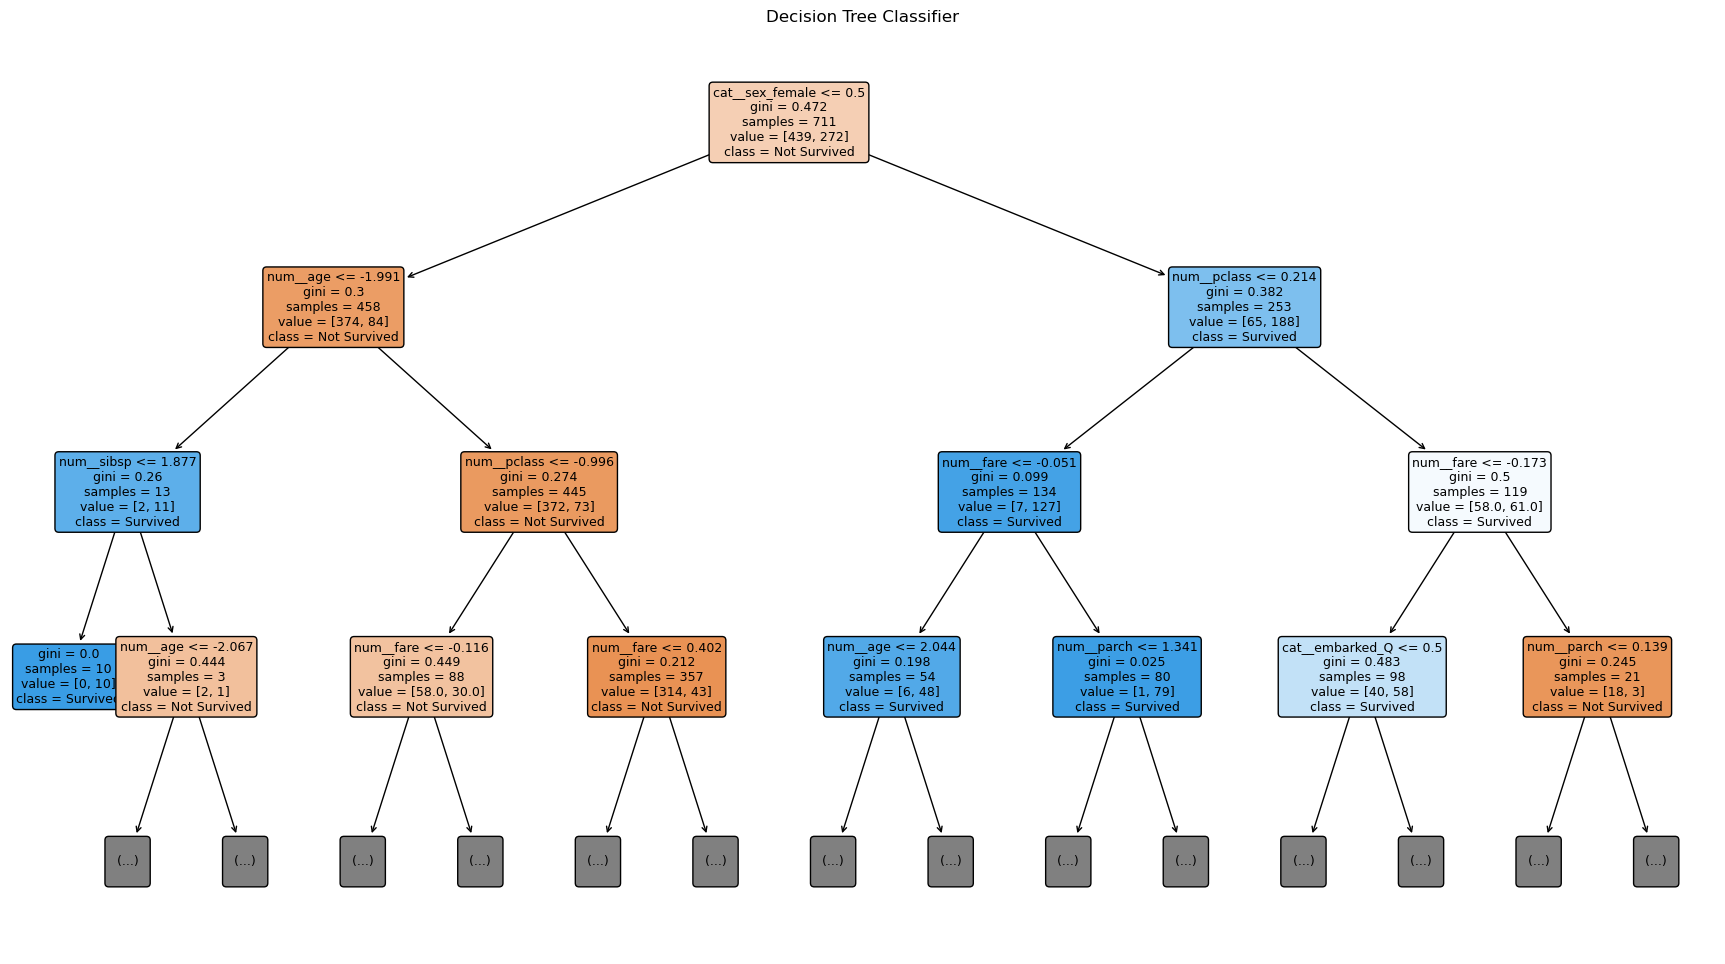

In [23]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Get the fitted preprocessing step and decision tree
decision_tree_pipeline = model_pipelines["Decision Tree"]

fitted_preprocessor = decision_tree_pipeline.named_steps["preprocessor"]
tree_model = decision_tree_pipeline.named_steps["model"]

# Get feature names after preprocessing
feature_names = fitted_preprocessor.get_feature_names_out()

# Plot the decision tree
plt.figure(figsize=(22, 12))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)

plt.title("Decision Tree Classifier")
plt.show()

In [24]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd

results = []

for name, pipeline in model_pipelines.items():
    # Predictions
    y_pred = pipeline.predict(X_test)

    # Probability for ROC-AUC
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": auc
    })

    print(f"\n=== {name} ===")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

metrics_df = pd.DataFrame(results)

print("\n=== MODEL PERFORMANCE COMPARISON ===")
print(metrics_df.round(4))


=== Logistic Regression ===
Confusion Matrix:
[[97 13]
 [21 47]]

=== Decision Tree ===
Confusion Matrix:
[[98 12]
 [30 38]]

=== Random Forest ===
Confusion Matrix:
[[95 15]
 [19 49]]

=== MODEL PERFORMANCE COMPARISON ===
                 Model  Accuracy  Precision  Recall      F1  ROC-AUC
0  Logistic Regression     0.809     0.7833  0.6912  0.7344   0.8610
1        Decision Tree     0.764     0.7600  0.5588  0.6441   0.8374
2        Random Forest     0.809     0.7656  0.7206  0.7424   0.8196


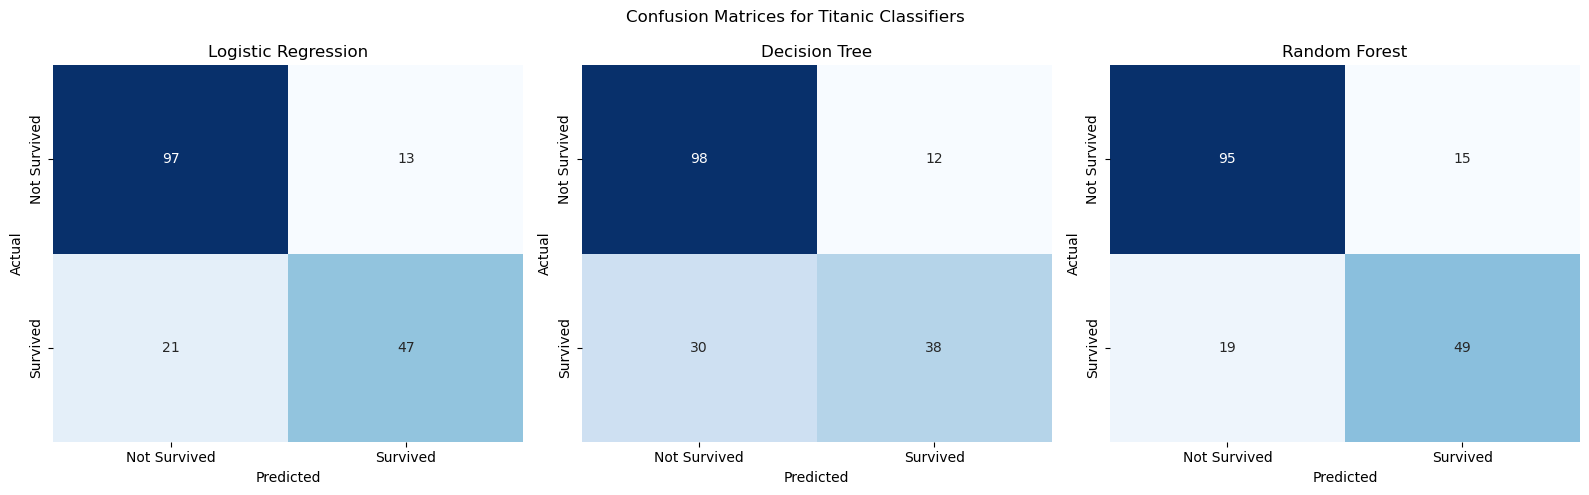

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, pipeline) in zip(axes, model_pipelines.items()):
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["Not Survived", "Survived"],
        yticklabels=["Not Survived", "Survived"]
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices for Titanic Classifiers")
plt.tight_layout()
plt.show()

In [26]:
print("=== CLASS DISTRIBUTION ===")

class_counts = y_train.value_counts()
class_percentages = y_train.value_counts(normalize=True) * 100

print("\nTraining class counts:")
print(class_counts)

print("\nTraining class percentages:")
print(class_percentages.round(2))

print("\nClass interpretation:")
print(
    f"Not Survived (0): {class_percentages[0]:.2f}%"
)
print(
    f"Survived (1): {class_percentages[1]:.2f}%"
)

print(
    "\nThe target variable has a moderate class imbalance, "
    "with more passengers not surviving than surviving."
)

=== CLASS DISTRIBUTION ===

Training class counts:
survived
0    439
1    272
Name: count, dtype: int64

Training class percentages:
survived
0    61.74
1    38.26
Name: proportion, dtype: float64

Class interpretation:
Not Survived (0): 61.74%
Survived (1): 38.26%

The target variable has a moderate class imbalance, with more passengers not surviving than surviving.


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Baseline Logistic Regression
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Class-weighted Logistic Regression
balanced_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

# Train both models
baseline_pipeline.fit(X_train, y_train)
balanced_pipeline.fit(X_train, y_train)

print("Baseline Logistic Regression trained.")
print("Class-weighted Logistic Regression trained.")

Baseline Logistic Regression trained.
Class-weighted Logistic Regression trained.


In [28]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# SMOTE Logistic Regression pipeline
smote_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Train only on the training data
smote_pipeline.fit(X_train, y_train)

print("SMOTE Logistic Regression trained successfully.")

SMOTE Logistic Regression trained successfully.


In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

imbalance_models = {
    "Baseline": baseline_pipeline,
    "Class Weighted": balanced_pipeline,
    "SMOTE": smote_pipeline
}

imbalance_results = []

for name, pipeline in imbalance_models.items():
    y_pred = pipeline.predict(X_test)

    imbalance_results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

imbalance_df = pd.DataFrame(imbalance_results)

print("=== IMBALANCE HANDLING COMPARISON ===")
print(imbalance_df.round(4))

=== IMBALANCE HANDLING COMPARISON ===
            Model  Precision  Recall      F1
0        Baseline     0.7833  0.6912  0.7344
1  Class Weighted     0.7183  0.7500  0.7338
2           SMOTE     0.7353  0.7353  0.7353


In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Random Forest pipeline for GridSearchCV
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            random_state=42,
            oob_score=True
        ))
    ]
)

# Hyperparameter grid
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10],
    "model__max_features": ["sqrt", "log2"]
}

# Grid search
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=1
)

# Train using training data only
rf_grid.fit(X_train, y_train)

print("GridSearchCV completed successfully.")

print("\n=== BEST PARAMETERS ===")
print(rf_grid.best_params_)

print("\n=== BEST CROSS-VALIDATION F1 ===")
print(round(rf_grid.best_score_, 4))

GridSearchCV completed successfully.

=== BEST PARAMETERS ===
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__n_estimators': 300}

=== BEST CROSS-VALIDATION F1 ===
0.7449


In [33]:
# Get the best fitted Random Forest pipeline
best_rf_pipeline = rf_grid.best_estimator_

# Get the fitted Random Forest model
best_rf_model = best_rf_pipeline.named_steps["model"]

print("=== BEST RANDOM FOREST ===")
print("Best parameters:")
print(rf_grid.best_params_)

print("\nBest cross-validation F1:")
print(round(rf_grid.best_score_, 4))

print("\nOOB Score:")
print(round(best_rf_model.oob_score_, 4))

=== BEST RANDOM FOREST ===
Best parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__n_estimators': 300}

Best cross-validation F1:
0.7449

OOB Score:
0.8073


In [34]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predictions from the tuned Random Forest
y_pred_best_rf = best_rf_pipeline.predict(X_test)
y_prob_best_rf = best_rf_pipeline.predict_proba(X_test)[:, 1]

# Calculate test metrics
best_rf_accuracy = accuracy_score(y_test, y_pred_best_rf)
best_rf_precision = precision_score(y_test, y_pred_best_rf)
best_rf_recall = recall_score(y_test, y_pred_best_rf)
best_rf_f1 = f1_score(y_test, y_pred_best_rf)
best_rf_auc = roc_auc_score(y_test, y_prob_best_rf)

print("=== TUNED RANDOM FOREST TEST RESULTS ===")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_rf))

print("\nAccuracy:", round(best_rf_accuracy, 4))
print("Precision:", round(best_rf_precision, 4))
print("Recall:", round(best_rf_recall, 4))
print("F1-score:", round(best_rf_f1, 4))
print("ROC-AUC:", round(best_rf_auc, 4))

=== TUNED RANDOM FOREST TEST RESULTS ===

Confusion Matrix:
[[95 15]
 [20 48]]

Accuracy: 0.8034
Precision: 0.7619
Recall: 0.7059
F1-score: 0.7328
ROC-AUC: 0.8237


In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Features used to predict fare
reg_features = [
    "survived",
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked"
]

X_reg = clean_df[reg_features]
y_reg = clean_df["fare"]

# Separate numeric and categorical features
reg_numeric_features = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch"
]

reg_categorical_features = [
    "sex",
    "embarked"
]

# Numeric preprocessing
reg_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
reg_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combined preprocessing
reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            reg_numeric_transformer,
            reg_numeric_features
        ),
        (
            "cat",
            reg_categorical_transformer,
            reg_categorical_features
        )
    ]
)

# Complete Linear Regression pipeline
regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        ("model", LinearRegression())
    ]
)

print("Regression features:")
print(reg_features)

print("\nRegression preprocessing pipeline created successfully.")

Regression features:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'embarked']

Regression preprocessing pipeline created successfully.


In [36]:
# Train/test split for regression
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("=== REGRESSION DATA SPLIT ===")
print("Training shape:", X_reg_train.shape)
print("Testing shape:", X_reg_test.shape)

# Train the complete regression pipeline
regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)

print("\nLinear Regression trained successfully.")

=== REGRESSION DATA SPLIT ===
Training shape: (711, 7)
Testing shape: (178, 7)

Linear Regression trained successfully.


In [37]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Predict fare on the test set
y_reg_pred = regression_pipeline.predict(X_reg_test)

# Basic regression metrics
mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

# Number of predictors after preprocessing
reg_fitted_preprocessor = (
    regression_pipeline.named_steps["preprocessor"]
)

n_predictors = len(
    reg_fitted_preprocessor.get_feature_names_out()
)

# Number of test observations
n = len(y_reg_test)

# Adjusted R-squared
adjusted_r2 = (
    1
    - (1 - r2)
    * (n - 1)
    / (n - n_predictors - 1)
)

print("=== LINEAR REGRESSION RESULTS ===")
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²:", round(r2, 4))
print("Adjusted R²:", round(adjusted_r2, 4))
print("Number of predictors after preprocessing:", n_predictors)

=== LINEAR REGRESSION RESULTS ===
MAE: 21.0986
RMSE: 41.7021
R²: 0.3482
Adjusted R²: 0.3091
Number of predictors after preprocessing: 10


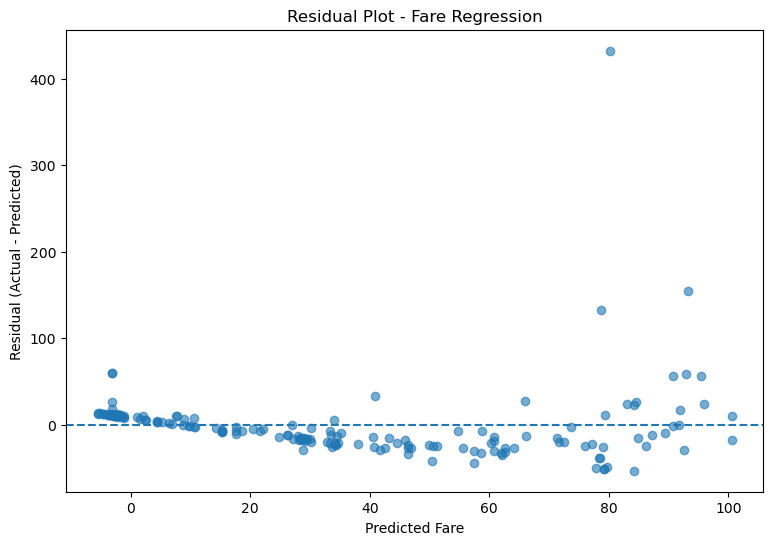

In [38]:
# Calculate residuals
residuals = y_reg_test - y_reg_pred

# Residual plot
plt.figure(figsize=(9, 6))

plt.scatter(
    y_reg_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot - Fare Regression")
plt.xlabel("Predicted Fare")
plt.ylabel("Residual (Actual - Predicted)")

plt.show()

In [39]:
# Classification results
classification_comparison = metrics_df.copy()

# Add tuned Random Forest
tuned_rf_row = pd.DataFrame([{
    "Model": "Tuned Random Forest",
    "Accuracy": best_rf_accuracy,
    "Precision": best_rf_precision,
    "Recall": best_rf_recall,
    "F1": best_rf_f1,
    "ROC-AUC": best_rf_auc
}])

classification_comparison = pd.concat(
    [classification_comparison, tuned_rf_row],
    ignore_index=True
)

print("=== CLASSIFICATION MODEL COMPARISON ===")
print(classification_comparison.round(4))

# Regression results
regression_comparison = pd.DataFrame([{
    "Model": "Multivariate Linear Regression",
    "MAE": mae,
    "RMSE": rmse,
    "R²": r2,
    "Adjusted R²": adjusted_r2
}])

print("\n=== REGRESSION MODEL COMPARISON ===")
print(regression_comparison.round(4))

=== CLASSIFICATION MODEL COMPARISON ===
                 Model  Accuracy  Precision  Recall      F1  ROC-AUC
0  Logistic Regression    0.8090     0.7833  0.6912  0.7344   0.8610
1        Decision Tree    0.7640     0.7600  0.5588  0.6441   0.8374
2        Random Forest    0.8090     0.7656  0.7206  0.7424   0.8196
3  Tuned Random Forest    0.8034     0.7619  0.7059  0.7328   0.8237

=== REGRESSION MODEL COMPARISON ===
                            Model      MAE     RMSE      R²  Adjusted R²
0  Multivariate Linear Regression  21.0986  41.7021  0.3482       0.3091


## Final Model Recommendation

For the Titanic classification task, the Random Forest achieved the highest F1-score among the original three classifiers at 0.7424, with an accuracy of 0.8090 and recall of 0.7206. Logistic Regression achieved the highest ROC-AUC at 0.8610 and the highest precision at 0.7833, while the Decision Tree had lower performance with an F1-score of 0.6441. The tuned Random Forest achieved a cross-validation F1-score of 0.7449 and an OOB score of 0.8073, but its test-set F1-score was 0.7328.

For the final classification pipeline, the Random Forest model is selected because it provides the highest test-set F1-score among the original classifiers and a stronger recall than Logistic Regression. The imbalance experiments showed that class weighting increased recall to 0.7500, while SMOTE produced a balanced precision and recall of 0.7353, with only a small change in F1 compared with the baseline. For fare prediction, Multivariate Linear Regression achieved an MAE of 21.0986, RMSE of 41.7021, R² of 0.3482, and adjusted R² of 0.3091; the widening residual spread indicates heteroscedasticity.

In [40]:
import joblib

# Select the original Random Forest pipeline
best_pipeline = model_pipelines["Random Forest"]

# Save the complete preprocessing + model pipeline
joblib.dump(
    best_pipeline,
    "best_model_pipeline.joblib"
)

print("Best model pipeline saved successfully.")
print("File: best_model_pipeline.joblib")

Best model pipeline saved successfully.
File: best_model_pipeline.joblib


In [41]:
import joblib
import pandas as pd

# Reload the saved complete pipeline
loaded_pipeline = joblib.load(
    "best_model_pipeline.joblib"
)

# Take one raw passenger record from the test set
raw_sample = X_test.iloc[[0]].copy()

# Predict using the reloaded pipeline
prediction = loaded_pipeline.predict(raw_sample)

print("=== RELOADED PIPELINE TEST ===")
print("\nRaw input:")
print(raw_sample)

print("\nPredicted survival:")
print(prediction[0])

print("\nActual survival:")
print(y_test.iloc[0])

print("\nPipeline reloaded and prediction completed successfully.")

=== RELOADED PIPELINE TEST ===

Raw input:
     pclass   sex   age  sibsp  parch  fare embarked  class  who  adult_male  \
160       3  male  44.0      0      1  16.1        S  Third  man        True   

     embark_town alive  alone  
160  Southampton    no  False  

Predicted survival:
0

Actual survival:
0

Pipeline reloaded and prediction completed successfully.
